### Load Data

In [2]:
from typing import Any
import re
from collections import defaultdict

def parse_iou_data(text: str):
    sparsity_pattern: re.Pattern[str] = re.compile(pattern=r"sparsity\s+([0-9.]+)")
    row_pattern: re.Pattern[str] = re.compile(pattern=r"\|\s*(.*?)\s*\|\s*([0-9.]+)\s*\|\s*([0-9.]+)\s*\|")

    data = defaultdict(dict)
    current_sparsity = None

    for line in text.splitlines():
        # detect sparsity
        s_match: re.Match[str] | None = sparsity_pattern.search(string=line)
        if s_match:
            current_sparsity = float(s_match.group(1))
            continue

        # detect table rows
        r_match: re.Match[str] | None = row_pattern.search(string=line)
        if r_match and current_sparsity is not None:
            cls: str | Any = r_match.group(1).strip()
            iou = float(r_match.group(2))

            # skip header
            if cls.lower() == "class":
                continue

            data[cls][current_sparsity] = iou

    return dict(data)

In [3]:
with open(file="val-results/results-mas2former-baseline-seed7-acdc-night.txt", mode="r") as f:
    text_seed7: str = f.read()

with open(file="val-results/results-mas2former-baseline-seed25-acdc-night.txt", mode="r") as f:
    text_seed_25: str = f.read()

with open(file="val-results/results-mas2former-baseline-seed42-acdc-night.txt", mode="r") as f:
    text_seed42: str = f.read()

with open(file="val-results/results-mas2former-baseline-seed11-acdc-night.txt", mode="r") as f:
    text_seed11: str = f.read()

with open(file="val-results/results-mas2former-baseline-seed14-acdc-night.txt", mode="r") as f:
    text_seed14: str = f.read()



data_seed7 = parse_iou_data(text_seed7)
data_seed25 = parse_iou_data(text_seed_25)
data_seed42 = parse_iou_data(text_seed42)
data_seed11 = parse_iou_data(text_seed11)
data_seed14 = parse_iou_data(text_seed14)

print(data_seed7["road"])
print(data_seed25["road"])
print(data_seed42["road"])
print(data_seed11["road"])
print(data_seed14["road"])

{0.0: 79.31, 0.4: 82.65, 0.5: 70.85, 0.6: 79.79, 0.7: 70.54, 0.8: 73.48, 0.9: 55.08}
{0.0: 69.04, 0.4: 76.9, 0.5: 83.75, 0.6: 79.66, 0.7: 79.24, 0.8: 81.48, 0.9: 72.09}
{0.0: 75.73, 0.4: 81.18, 0.5: 78.06, 0.6: 86.14, 0.7: 87.82, 0.8: 70.57, 0.9: 68.5}
{0.0: 74.63, 0.4: 71.83, 0.5: 65.35, 0.6: 61.85, 0.7: 62.16, 0.8: 63.56, 0.9: 68.83}
{0.0: 59.35, 0.4: 63.29, 0.5: 62.04, 0.6: 62.87, 0.7: 58.98, 0.8: 71.72, 0.9: 68.58}


### Create plots per seed

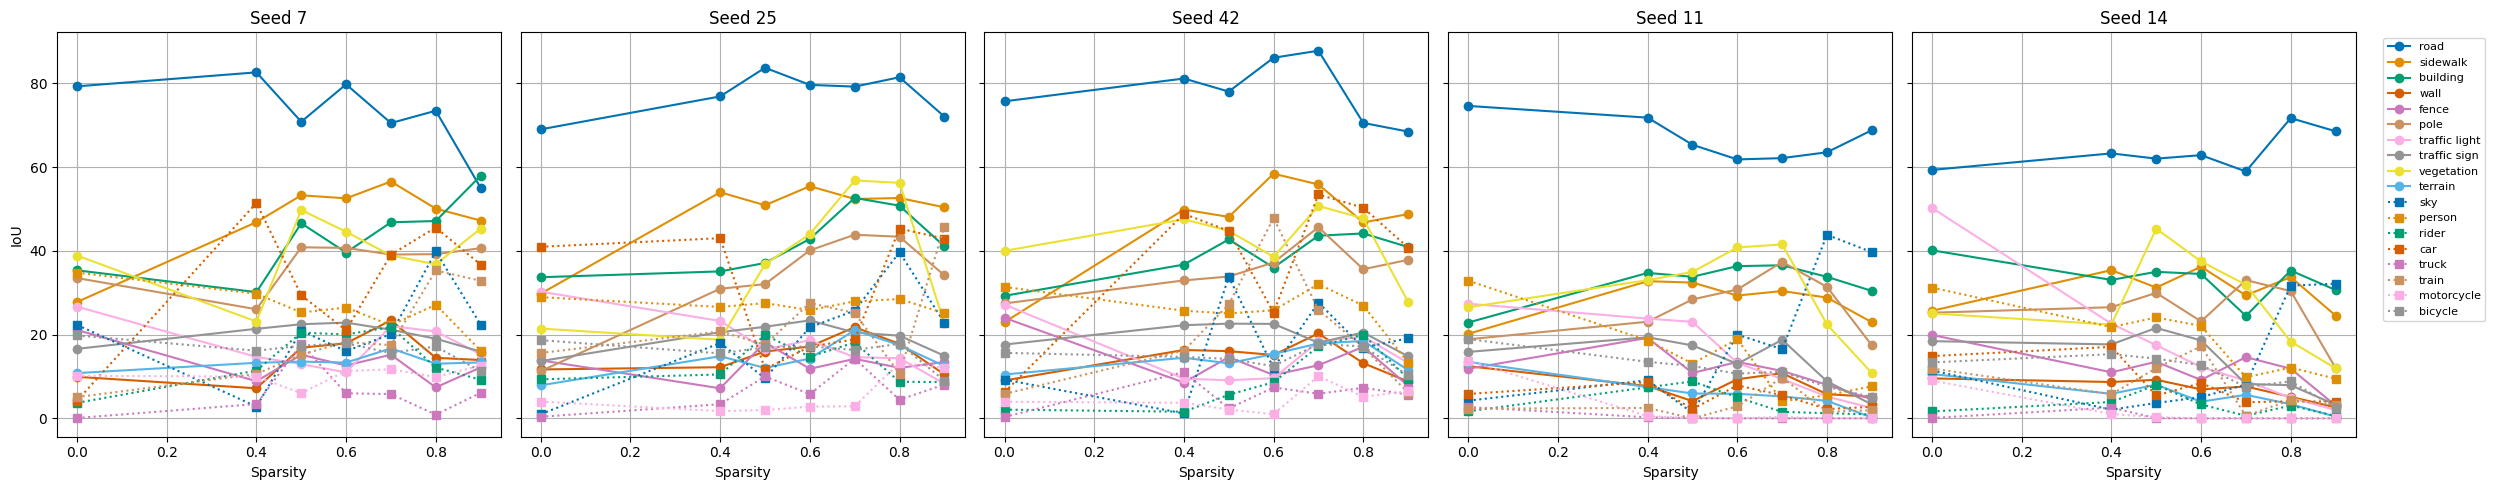

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharey=True)

datasets = [data_seed7, data_seed25, data_seed42, data_seed11, data_seed14]
titles = ["Seed 7", "Seed 25", "Seed 42", "Seed 11", "Seed 14"]

classes = list(datasets[0].keys())

colors = sns.color_palette("colorblind", 10)

for ax, data, title in zip(axes, datasets, titles):
    sparsities = sorted({s for cls in data.values() for s in cls})

    for i, cls in enumerate(classes):
        y = [data[cls].get(s, None) for s in sparsities]

        if i < 10:
            linestyle = '-'
            marker = 'o'
        else:
            linestyle = ':'
            marker = 's'

        ax.plot(sparsities, y,
                marker=marker,
                label=cls,
                color=colors[i % 10],
                linestyle=linestyle)

    ax.set_title(title)
    ax.set_xlabel("Sparsity")
    ax.grid(True)

axes[0].set_ylabel("IoU")

handles, labels = axes[0].get_legend_handles_labels()

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
import numpy as np

datasets = [data_seed7, data_seed25, data_seed42, data_seed11, data_seed14]
classes = list(datasets[0].keys())

# collect all sparsities
sparsities = sorted({s for d in datasets for cls in d.values() for s in cls})

mean_data = {}
std_data = {}

for cls in classes:
    mean_vals = []
    std_vals = []

    for s in sparsities:
        vals = [d[cls][s] for d in datasets if s in d[cls]]

        #mean_vals.append(np.mean(vals))
        mean_vals.append(np.median(vals))
        #std_vals.append(np.std(vals, ddof=1))  
        std_vals.append(np.std(vals, ddof=1) / np.sqrt(len(vals)))

    mean_data[cls] = mean_vals
    std_data[cls] = std_vals

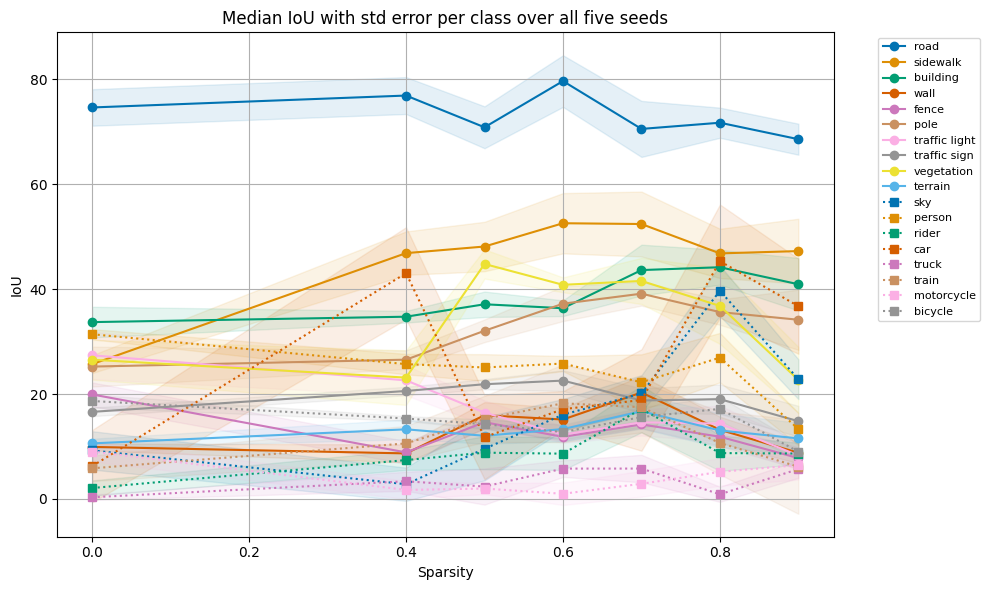

In [6]:
colors = sns.color_palette("colorblind", len(classes))

plt.figure(figsize=(10, 6))

for i, cls in enumerate(classes):
    y = mean_data[cls]
    y_std = std_data[cls]

    if i < 10:
        linestyle = '-'
        marker = 'o'
 
    else:
        linestyle = ':'
        marker = 's'

    plt.plot(sparsities, y,
             label=cls,
             color=colors[i % 10],
             marker=marker,
             linestyle=linestyle)

    # shaded std
    plt.fill_between(
        sparsities,
        np.array(y) - np.array(y_std),
        np.array(y) + np.array(y_std),
        color=colors[i % 10],
        alpha=0.1
    )

plt.xlabel("Sparsity")
plt.ylabel("IoU")
plt.title("Median IoU with std error per class over all five seeds")
plt.grid(True)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

### Calculate per-class mean for the acdc_night val set

In [7]:
from pathlib import Path
from PIL import Image
import numpy as np

acdc_night_val_path = Path("/home/lstracke/Data/acdc/gt/night/val")
acdc_mask_list = list(acdc_night_val_path.glob("**/*_gt_labelTrainIds.png"))
values = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 255])

acc = np.zeros(20)
for i in acdc_mask_list:
    image = np.array(Image.open(i))
    cnts, vals = np.histogram(image, bins=values)
    for v, c in zip(vals.tolist(), cnts.tolist()):
        acc[values==v] += c

class_distribution = acc.tolist()
pixel_count = len(acdc_mask_list) * np.array(Image.open(acdc_mask_list[0])).size
percentage =[x / pixel_count for x in class_distribution]
print("Images:", len(acdc_mask_list))
print("poiad")
print("Class Distr.:", class_distribution)
print("Pixels:", pixel_count)
print("Percentage", percentage)
print(sum(percentage))

Images: 106
poiad
Class Distr.: [53593801.0, 17431927.0, 38090122.0, 4022306.0, 5122854.0, 1600887.0, 172791.0, 774115.0, 38089324.0, 2197247.0, 36795621.0, 350880.0, 21587.0, 1141109.0, 31471.0, 0.0, 2457411.0, 82299.0, 17825848.0, 0.0]
Pixels: 219801600
Percentage [0.24382807495486838, 0.07930755281126252, 0.17329319713778243, 0.01829971210400652, 0.023306718422431864, 0.00728332732791754, 0.0007861225759958071, 0.0035218806414511997, 0.17328956659096204, 0.009996501390344747, 0.16740379050925927, 0.0015963487071977637, 9.821129600512463e-05, 0.005191540916899604, 0.00014317912153505706, 0.0, 0.011180132446715584, 0.00037442402603074775, 0.0810997190193338, 0.0]
1.0


In [8]:
import numpy as np

datasets = [data_seed7, data_seed25, data_seed42, data_seed11, data_seed14]
classes = list(datasets[0].keys())

# collect all sparsities
sparsities = sorted({s for d in datasets for cls in d.values() for s in cls})

mean_data = {}
std_data = {}

for i, cls in enumerate(classes):
    mean_vals = []
    std_vals = []

    for s in sparsities:
        vals = [d[cls][s] for d in datasets if s in d[cls]]
        normalized_vals = [(x * class_distribution[i])/ pixel_count for x in vals]
        #mean_vals.append(np.mean(vals))
        mean_vals.append(np.median(normalized_vals))
        #std_vals.append(np.std(vals, ddof=1))  
        std_vals.append(np.std(normalized_vals, ddof=1) / np.sqrt(len(vals)))

    mean_data[cls] = mean_vals
    std_data[cls] = std_vals

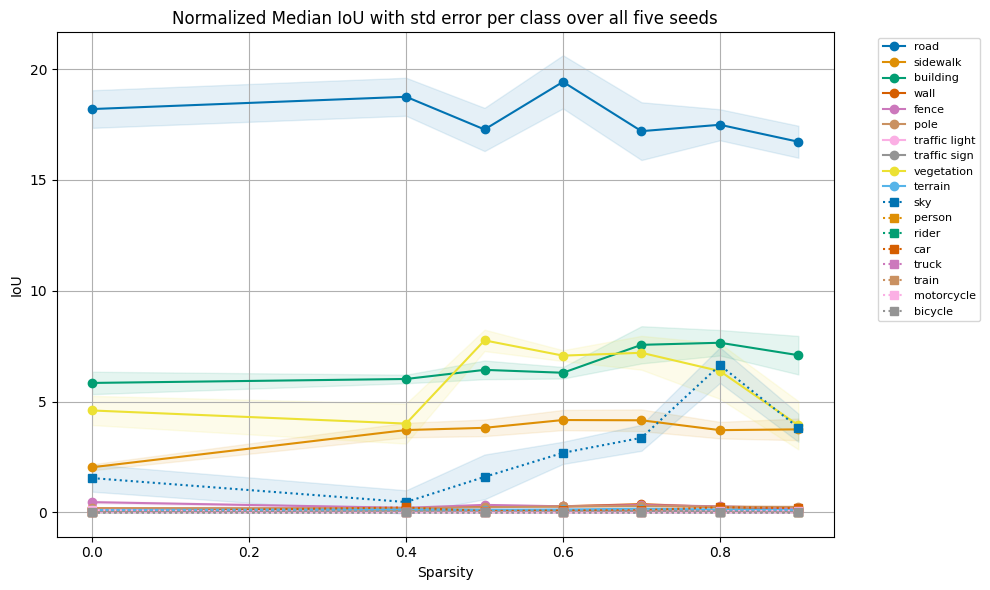

In [9]:
colors = sns.color_palette("colorblind", len(classes))

plt.figure(figsize=(10, 6))

for i, cls in enumerate(classes):
    y = mean_data[cls]
    y_std = std_data[cls]

    if i < 10:
        linestyle = '-'
        marker = 'o'
 
    else:
        linestyle = ':'
        marker = 's'

    plt.plot(sparsities, y,
             label=cls,
             color=colors[i % 10],
             marker=marker,
             linestyle=linestyle)

    # shaded std
    plt.fill_between(
        sparsities,
        np.array(y) - np.array(y_std),
        np.array(y) + np.array(y_std),
        color=colors[i % 10],
        alpha=0.1
    )

plt.xlabel("Sparsity")
plt.ylabel("IoU")
plt.title("Normalized Median IoU with std error per class over all five seeds")
plt.grid(True)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

### Same with co-preprocessing


In [10]:
with open(file="val-results/results-mas2former-baseline-seed7-co-acdc-night.txt", mode="r") as f:
    text_co_seed7: str = f.read()

with open(file="val-results/results-mas2former-baseline-seed25-co-acdc-night.txt", mode="r") as f:
    text_co_seed_25: str = f.read()

with open(file="val-results/results-mas2former-baseline-seed42-co-acdc-night.txt", mode="r") as f:
    text_co_seed42: str = f.read()




data_seed7_co = parse_iou_data(text_co_seed7)
data_seed25_co = parse_iou_data(text_co_seed_25)
data_seed42_co = parse_iou_data(text_co_seed42)

print(data_seed7_co["road"])
print(data_seed25_co["road"])
print(data_seed42_co["road"])

{0.0: 84.13, 0.4: 90.17, 0.5: 88.76, 0.6: 82.5, 0.7: 87.25, 0.8: 87.33, 0.9: 79.86}
{0.0: 86.03, 0.4: 86.06, 0.5: 85.72, 0.6: 84.16, 0.7: 85.79, 0.8: 76.82, 0.9: 83.98}
{0.0: 82.07, 0.4: 84.74, 0.5: 86.54, 0.6: 81.75, 0.7: 79.38, 0.8: 82.09, 0.9: 87.85}


In [11]:
import numpy as np

datasets = [data_seed7_co, data_seed25_co, data_seed42_co]
classes = list(datasets[0].keys())

# collect all sparsities
sparsities = sorted({s for d in datasets for cls in d.values() for s in cls})

mean_data = {}
std_data = {}

for i, cls in enumerate(classes):
    mean_vals = []
    std_vals = []

    for s in sparsities:
        vals = [d[cls][s] for d in datasets if s in d[cls]]
        normalized_vals = [(x * class_distribution[i])/ pixel_count for x in vals]
        #mean_vals.append(np.mean(vals))
        mean_vals.append(np.median(normalized_vals))
        #std_vals.append(np.std(vals, ddof=1))  
        std_vals.append(np.std(normalized_vals, ddof=1) / np.sqrt(len(vals)))

    mean_data[cls] = mean_vals
    std_data[cls] = std_vals

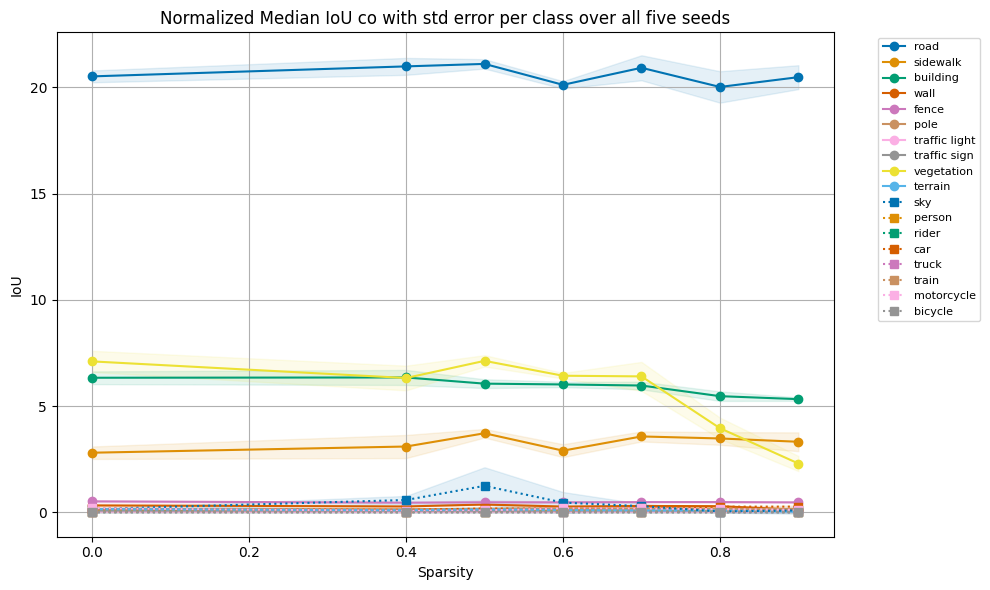

In [12]:
colors = sns.color_palette("colorblind", len(classes))

plt.figure(figsize=(10, 6))

for i, cls in enumerate(classes):
    y = mean_data[cls]
    y_std = std_data[cls]

    if i < 10:
        linestyle = '-'
        marker = 'o'
 
    else:
        linestyle = ':'
        marker = 's'

    plt.plot(sparsities, y,
             label=cls,
             color=colors[i % 10],
             marker=marker,
             linestyle=linestyle)

    # shaded std
    plt.fill_between(
        sparsities,
        np.array(y) - np.array(y_std),
        np.array(y) + np.array(y_std),
        color=colors[i % 10],
        alpha=0.1
    )

plt.xlabel("Sparsity")
plt.ylabel("IoU")
plt.title("Normalized Median IoU co with std error per class over all five seeds")
plt.grid(True)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

### Comparison of both in one plot

In [13]:
datasets_no_co = [data_seed7, data_seed25, data_seed42, data_seed11, data_seed14]
datasets_co = [data_seed7_co, data_seed25_co, data_seed42_co]

classes = list(datasets_no_co[0].keys())

colors = sns.color_palette("colorblind", len(classes))


def compute_stats(datasets):
    sparsities = sorted({
        s for d in datasets
        for cls in d.values()
        for s in cls
    })

    mean_data = {}
    std_data = {}

    for i, cls in enumerate(classes):
        mean_vals = []
        std_vals = []

        for s in sparsities:
            vals = [d[cls][s] for d in datasets if s in d[cls]]

            normalized_vals = [
                (x * class_distribution[i]) / pixel_count
                for x in vals
            ]

            mean_vals.append(np.median(normalized_vals))
            std_vals.append(
                np.std(normalized_vals, ddof=1) / np.sqrt(len(vals))
            )

        mean_data[cls] = mean_vals
        std_data[cls] = std_vals

    return sparsities, mean_data, std_data


# compute separately
sparsities_no_co, mean_no_co, std_no_co = compute_stats(datasets_no_co)
sparsities_co, mean_co, std_co = compute_stats(datasets_co)

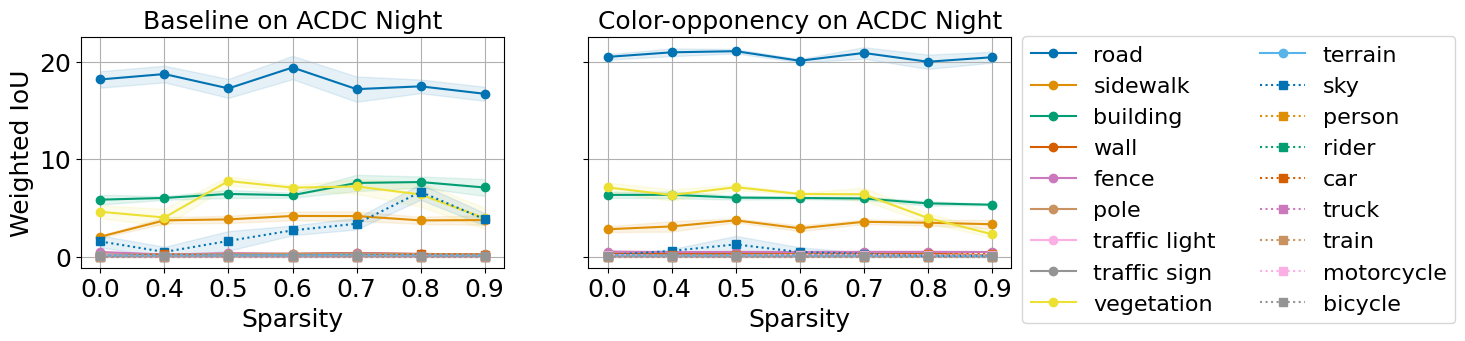

In [ ]:
from PIL.ImageOps import pad
fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)

titles = ["Baseline on ACDC Night", "Color-opponency on ACDC Night"]
plot_data = [
    (axes[0], sparsities_no_co, mean_no_co, std_no_co),
    (axes[1], sparsities_co, mean_co, std_co)
]


x_display = np.array([0.0] + list(np.arange(0.4, 1.0, 0.1)))
x_pos = np.arange(len(x_display))

for ax, sparsities, mean_data, std_data in plot_data:

    for i, cls in enumerate(classes):

        y = mean_data[cls]
        y_std = std_data[cls]

        if i < 10:
            linestyle = '-'
            marker = 'o'
        else:
            linestyle = ':'
            marker = 's'

        ax.plot(
            x_pos,
            y,
            label=cls,
            color=colors[i % 10],
            marker=marker,
            linestyle=linestyle
        )

        ax.fill_between(
            x_pos,
            np.array(y) - np.array(y_std),
            np.array(y) + np.array(y_std),
            color=colors[i % 10],
            alpha=0.1
        )

# formatting
axes[0].set_title(titles[0], fontsize=18)
axes[1].set_title(titles[1], fontsize=18)


for ax in axes:
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{x:.1f}" for x in x_display], fontsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_xlabel("Sparsity", fontsize=18)
    ax.grid(True)
    

axes[0].set_ylabel("Weighted IoU", fontsize=18)

# legend only once
axes[1].legend(
    bbox_to_anchor=(1, 1.05),
    loc="upper left",
    fontsize=16,
    ncol=2
)

#plt.tight_layout()
plt.show()

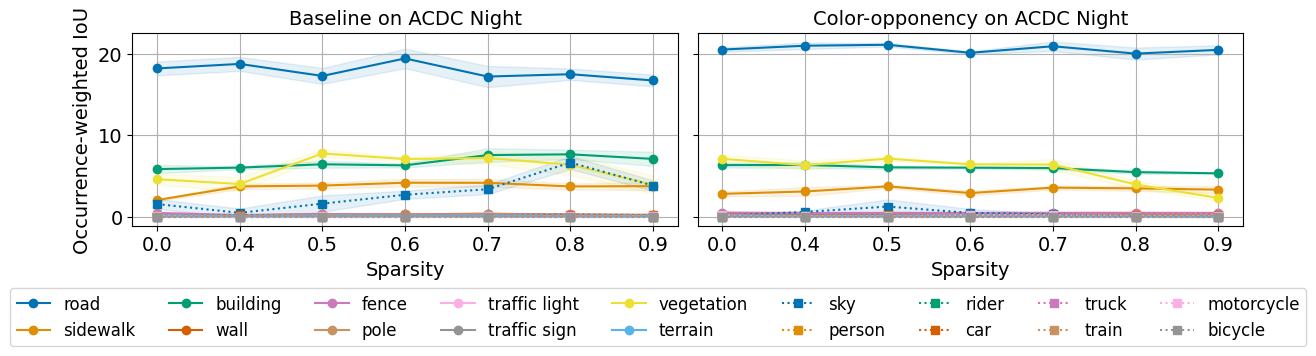

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)

titles = ["Baseline on ACDC Night", "Color-opponency on ACDC Night"]
plot_data = [
    (axes[0], sparsities_no_co, mean_no_co, std_no_co),
    (axes[1], sparsities_co, mean_co, std_co)
]


x_display = np.array([0.0] + list(np.arange(0.4, 1.0, 0.1)))
x_pos = np.arange(len(x_display))

for ax, sparsities, mean_data, std_data in plot_data:

    for i, cls in enumerate(classes):

        y = mean_data[cls]
        y_std = std_data[cls]

        if i < 10:
            linestyle = '-'
            marker = 'o'
        else:
            linestyle = ':'
            marker = 's'

        ax.plot(
            x_pos,
            y,
            label=cls,
            color=colors[i % 10],
            marker=marker,
            linestyle=linestyle
        )

        ax.fill_between(
            x_pos,
            np.array(y) - np.array(y_std),
            np.array(y) + np.array(y_std),
            color=colors[i % 10],
            alpha=0.1
        )

# formatting
axes[0].set_title(titles[0], fontsize=14)
axes[1].set_title(titles[1], fontsize=14)


for ax in axes:
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{x:.1f}" for x in x_display], fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xlabel("Sparsity", fontsize=14)
    ax.grid(True)
    

axes[0].set_ylabel("Occurrence-weighted IoU", fontsize=14)

# legend only once
handles, labels = axes[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.2),
    fontsize=12,
    ncol=9,
)

plt.tight_layout()
plt.show()